In [ ]:
#Match analysis using pandas
#Analysing the impact of Impact player rule (introduced in 2023) on high level game statistics

import pandas as pd
deliveries = pd.read_csv('deliveries.csv')
matches = pd.read_csv('matches.csv')
matches['city'] = matches['city'].fillna('Unknown')
matches['player_of_match'] = matches['player_of_match'].fillna('None')
matches['winner'] = matches['winner'].fillna('No Result')
matches['result_margin'] = matches['result_margin'].fillna(0)
matches['target_runs'] = matches['target_runs'].fillna(0)
matches['target_overs'] = matches['target_overs'].fillna(0)
matches['method'] = matches['method'].fillna('Normal')


deliveries['extras_type'] = deliveries['extras_type'].fillna('None')
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna('None')
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].fillna('None')
deliveries['fielder'] = deliveries['fielder'].fillna('None')

In [88]:
matches.columns = matches.columns.str.lower()
deliveries.columns = deliveries.columns.str.lower()
matches.rename(columns={'id':'match_id'}, inplace=True)
df = deliveries.merge(matches, on = 'match_id', how = 'left')


In [89]:
df['season'] = df['season'].str[:4].astype(int)
pre_df = df[df['season'] < 2023]
post_df = df[df['season'] >= 2023]

In [90]:
def compute_strike_rate(data):
    valid_balls = data[data['extras_type'] != 'wides']

    batter_stats = valid_balls.groupby('batter').agg({
        'batsman_runs': 'sum',
        'ball': 'count'
    })

    batter_stats['strike_rate'] = (
        batter_stats['batsman_runs'] / batter_stats['ball']
    ) * 100

    return batter_stats['strike_rate'].mean()

def compute_economy(data):
    bowler_stats = data.groupby('bowler').agg({
        'total_runs': 'sum',
        'ball': 'count'
    })

    bowler_stats['overs'] = bowler_stats['ball'] / 6

    bowler_stats['economy'] = (
        bowler_stats['total_runs'] / bowler_stats['overs']
    )

    return bowler_stats['economy'].mean()

def avg_runs_per_match(data):
    return (
        data.groupby('match_id')['total_runs']
        .sum()
        .mean()
    )

def avg_wickets(data):
    return (
        data.groupby('match_id')['is_wicket']
        .sum()
        .mean()
    )



In [91]:
pre_sr = compute_strike_rate(pre_df)
post_sr = compute_strike_rate(post_df)

print(pre_sr, post_sr)

pre_econ = compute_economy(pre_df)
post_econ = compute_economy(post_df)

print(pre_econ, post_econ)

pre_runs = avg_runs_per_match(pre_df)
post_runs = avg_runs_per_match(post_df)

print(pre_runs, post_runs)

pre_wickets = avg_wickets(pre_df)
post_wickets = avg_wickets(post_df)

print(pre_wickets, post_wickets)

103.65165760427524 120.72258866996397
8.731933474940037 9.680584141099699
311.68105263157895 356.2689655172414
11.737894736842104 12.406896551724138


In [92]:
comparison = {
    "Metric": ["Strike Rate", "Economy", "Avg Runs", "Avg Wickets"],
    "Pre-2023": [pre_sr, pre_econ, pre_runs, pre_wickets],
    "Post-2023": [post_sr, post_econ, post_runs, post_wickets]
}

print(comparison)

{'Metric': ['Strike Rate', 'Economy', 'Avg Runs', 'Avg Wickets'], 'Pre-2023': [np.float64(103.65165760427524), np.float64(8.731933474940037), np.float64(311.68105263157895), np.float64(11.737894736842104)], 'Post-2023': [np.float64(120.72258866996397), np.float64(9.680584141099699), np.float64(356.2689655172414), np.float64(12.406896551724138)]}


In [93]:
def yearly_strike_rate(data):
    valid_balls = data[data['extras_type'] != 'wides']

    batter_stats = valid_balls.groupby(['season', 'batter']).agg({
        'batsman_runs': 'sum',
        'ball': 'count'
    }).reset_index()

    batter_stats['strike_rate'] = (
        batter_stats['batsman_runs'] / batter_stats['ball']
    ) * 100

    
    return batter_stats.groupby('season')['strike_rate'].mean()

def yearly_economy(data):
    # remove wides and no-balls
    legal_balls = data[
        (data['extras_type'] != 'wides') &
        (data['extras_type'] != 'noballs')
    ]

    bowler_stats = legal_balls.groupby(['season', 'bowler']).agg({
        'total_runs': 'sum',
        'ball': 'count'
    }).reset_index()

    bowler_stats['overs'] = bowler_stats['ball'] / 6

    bowler_stats['economy'] = (
        bowler_stats['total_runs'] / bowler_stats['overs']
    )

    return bowler_stats.groupby('season')['economy'].mean()


def yearly_avg_runs(data):
    match_runs = data.groupby(['season', 'match_id'])['total_runs'].sum().reset_index()

    return match_runs.groupby('season')['total_runs'].mean()

def yearly_wickets(data):
    match_wickets = data.groupby(['season', 'match_id'])['is_wicket'].sum().reset_index()

    return match_wickets.groupby('season')['is_wicket'].mean()

In [94]:
import matplotlib.pyplot as plt

def plot_trend(series, title, ylabel):
    plt.figure()

    plt.plot(series.index, series.values, marker='o')
    plt.xticks(range(min(sr.index), max(sr.index)+1, 2))
    # vertical line at 2023
    plt.axvline(x=2023, linestyle='--')

    plt.title(title)
    plt.xlabel('Season')
    plt.ylabel(ylabel)

    plt.grid()
    plt.show()

In [95]:
deliveries = deliveries.merge(
    matches[['match_id', 'season']],
    on='match_id',
    how='left'
)
deliveries['season'] = deliveries['season'].astype(str).str[:4].astype(int)

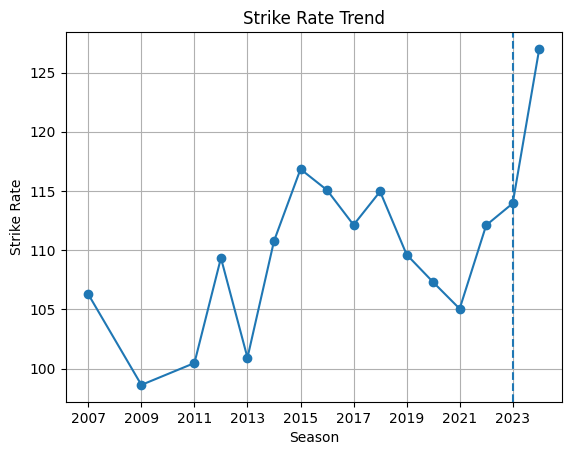

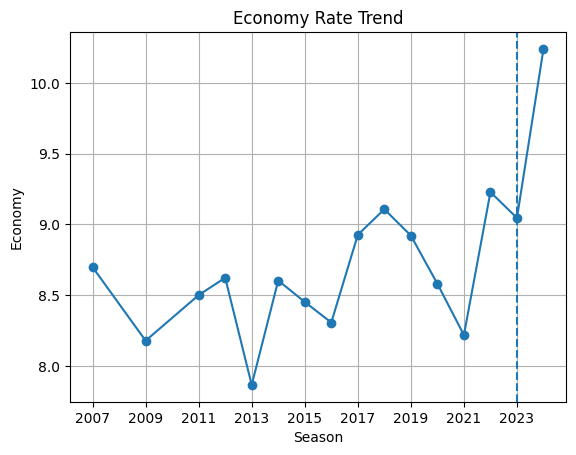

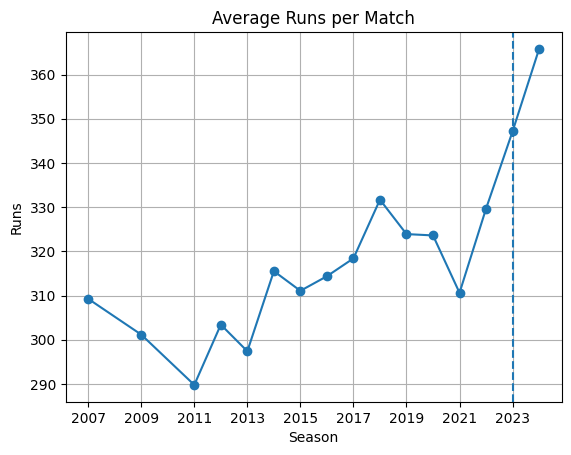

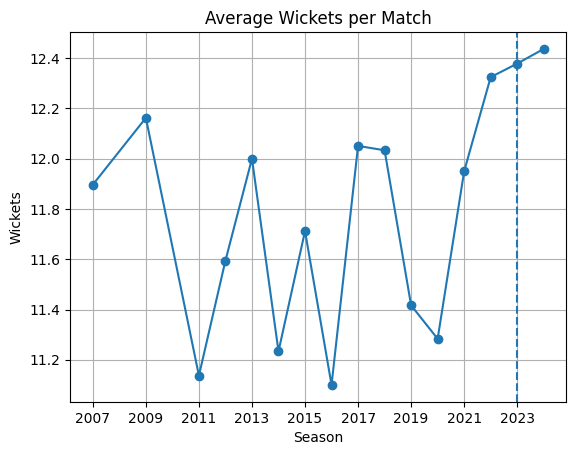

In [96]:
sr = yearly_strike_rate(deliveries)
eco = yearly_economy(deliveries)
runs = yearly_avg_runs(deliveries)
wkts = yearly_wickets(deliveries)

plot_trend(sr, "Strike Rate Trend", "Strike Rate")
plot_trend(eco, "Economy Rate Trend", "Economy")
plot_trend(runs, "Average Runs per Match", "Runs")
plot_trend(wkts, "Average Wickets per Match", "Wickets")

In [97]:
valid_balls = df[df['extras_type'] != 'wides']
yearly_sr = (
    valid_balls.groupby(['season', 'batter'])
    .agg({
        'batsman_runs' : 'sum',
        'ball' : 'count'
    })
)
yearly_sr['strike_rate'] = (
    yearly_sr['batsman_runs'] / yearly_sr['ball']
) * 100
yearly_avg_sr = (
    yearly_sr.groupby('season')['strike_rate']
    .mean()
    .reset_index()
)

In [110]:
train = yearly_avg_sr[
    (yearly_avg_sr['season'] >= 2021) &
    (yearly_avg_sr['season'] < 2023)
]
test = yearly_avg_sr[yearly_avg_sr['season'] >= 2023]



In [ ]:

from sklearn.linear_model import LinearRegression
#performing  a prediction based on pre impact player era data to demonstrate its impact
x_train = train[['season']]
y_train = train['strike_rate']

model = LinearRegression()
model.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [112]:
X_test = test[['season']]
predictions = model.predict(X_test)
test['predicted_sr'] = predictions

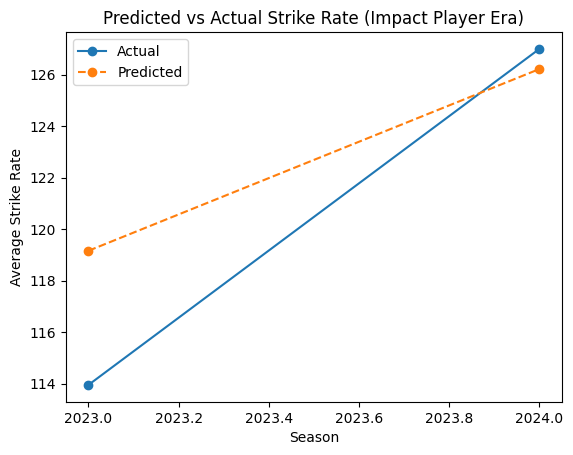

In [113]:
import matplotlib.pyplot as plt

plt.figure()


plt.plot(
    test['season'],
    test['strike_rate'],
    marker='o',
    label='Actual'
)


plt.plot(
    test['season'],
    test['predicted_sr'],
    marker='o',
    linestyle='--',
    label='Predicted'
)

plt.xlabel('Season')
plt.ylabel('Average Strike Rate')
plt.title('Predicted vs Actual Strike Rate (Impact Player Era)')
plt.legend()

plt.show()